<a href="https://colab.research.google.com/github/GuiOlympio/Classificacao_mri_alzheimer_cnn/blob/Xception/IcGuilherme_Xception_CNN_teste_independente.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
import time

path = kagglehub.dataset_download("lukechugh/best-alzheimer-mri-dataset-99-accuracy")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'best-alzheimer-mri-dataset-99-accuracy' dataset.
Path to dataset files: /kaggle/input/best-alzheimer-mri-dataset-99-accuracy


In [ ]:
import os

#obtem o nome do caminho das base de teste e treino
print("Conteúdo da pasta do dataset:")
print(os.listdir(path))

Conteúdo da pasta do dataset:
['Combined Dataset']


In [ ]:
dataset_dir = os.path.join(path, "Combined Dataset")

print("Conteúdo da pasta Combined Dataset:")
print(os.listdir(dataset_dir))

Conteúdo da pasta Combined Dataset:
['test', 'train']


In [ ]:
train = os.path.join(dataset_dir, "train")

print("Conteúdo da pasta train:")
print(os.listdir(train))

Conteúdo da pasta train:
['No Impairment', 'Very Mild Impairment', 'Moderate Impairment', 'Mild Impairment']


In [ ]:
import pathlib
caminho = pathlib.Path(train)

categorias = [d.name for d in caminho.iterdir() if d.is_dir()]

for categoria in categorias:
    print(f" - {categoria}")

 - No Impairment
 - Very Mild Impairment
 - Moderate Impairment
 - Mild Impairment


In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import pathlib, os, shutil
import hashlib


caminho = pathlib.Path(train)
diretorio_subconjunto = pathlib.Path("subconjunto de Alzheimer")

if diretorio_subconjunto.exists():
    shutil.rmtree(diretorio_subconjunto)

categorias = ['No Impairment', 'Moderate Impairment']

def redimensiona_com_padding(caminho_img, tamanho_alvo=(224, 224)):

    """
     Redimensiona a imagem mantendo a proporção original do cérebro
     e preenche as bordas com fundo preto (0,0,0) até atingir 224x224.
    """
    img = cv2.imread(str(caminho_img))
    if img is None:
        return None

    h, w, _ = img.shape
    alvo_h, alvo_w = tamanho_alvo

    # Mantém a escala exata da anatomia
    escala = min(alvo_w / w, alvo_h / h)
    novo_w, novo_h = int(w * escala), int(h * escala)

    img_redim = cv2.resize(img, (novo_w, novo_h), interpolation=cv2.INTER_AREA)

    # Tela preta de fundo
    img_pad = np.zeros((alvo_h, alvo_w, 3), dtype=np.uint8)

    # Centraliza a ressonância
    top = (alvo_h - novo_h) // 2
    left = (alvo_w - novo_w) // 2
    img_pad[top:top+novo_h, left:left+novo_w] = img_redim

    return cv2.cvtColor(img_pad, cv2.COLOR_BGR2RGB)

# Pega 10 amostras do dataset limpo para exibição
amostras = list((diretorio_subconjunto / "treino" / "No Impairment").glob("*"))[:10]

plt.figure(figsize=(15, 6))
for idx, img_path in enumerate(amostras):
    img_padded = redimensiona_com_padding(img_path)
    plt.subplot(2, 5, idx + 1)
    plt.imshow(img_padded)
    plt.title(f"Amostra {idx + 1}\n224x224 (Padded)", fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()


<Figure size 1500x600 with 0 Axes>

In [ ]:
def processa_e_filtra_categorias():
    dados_filtrados = {}

    print("=== RELATÓRIO DE FILTRAGEM DE IMAGENS ===")
    for categoria in categorias:
        categoria_diretorio = caminho / categoria

        hashes_vistos = set()
        fnomes_validos = []

        qtd_total = 0
        qtd_ruido = 0
        qtd_duplicadas = 0

        arquivos = os.listdir(categoria_diretorio)
        qtd_total = len(arquivos)

        for fnome in arquivos:
            img_path = categoria_diretorio / fnome

            # 1. Filtro de ruído / imagens vazias ou corrompidas
            img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
            if img is None or np.var(img) < 100.0:
                qtd_ruido += 1
                continue

            # 2. Filtro de duplicatas (MD5 Hash)
            with open(img_path, "rb") as f:
                h = hashlib.md5(f.read()).hexdigest()

            if h in hashes_vistos:
                qtd_duplicadas += 1
                continue

            hashes_vistos.add(h)
            fnomes_validos.append(fnome)

        dados_filtrados[categoria] = fnomes_validos

        print(f"\nCategoria: [{categoria}]")
        print(f" - Total de arquivos analisados : {qtd_total}")
        print(f" - Imagens com ruído/invalidas   : {qtd_ruido}")
        print(f" - Imagens duplicadas           : {qtd_duplicadas}")
        print(f" - Imagens válidas mantidas     : {len(fnomes_validos)}")

    return dados_filtrados

# 1. Executa a filtragem e exibe o relatório
arquivos_validos_por_categoria = processa_e_filtra_categorias()

# 2. Função para copiar as imagens válidas já filtradas
def copia_subconjunto(subconjunto_nome, inicia_index, finaliza_index):
    for categoria, fnomes_validos in arquivos_validos_por_categoria.items():
        diretorio_destino = diretorio_subconjunto / subconjunto_nome / categoria
        os.makedirs(diretorio_destino, exist_ok=True)

        fnomes = fnomes_validos[inicia_index:finaliza_index]

        for fnome in fnomes:
            caminho_origem = caminho / categoria / fnome

            # LER E APLICAR O PADDING ANTES DE SALVAR
            img_padded_rgb = redimensiona_com_padding(caminho_origem, tamanho_alvo=(224, 224))
            if img_padded_rgb is not None:
                # Converter de RGB de volta para BGR para salvar com OpenCV
                img_bgr = cv2.cvtColor(img_padded_rgb, cv2.COLOR_RGB2BGR)
                cv2.imwrite(str(diretorio_destino / fnome), img_bgr)

# 3. Cria as divisões
copia_subconjunto("treino", inicia_index=0, finaliza_index=2000)
copia_subconjunto("validacao", inicia_index=2000, finaliza_index=None)
#copia_subconjunto("teste", inicia_index=2000, finaliza_index=None)

=== RELATÓRIO DE FILTRAGEM DE IMAGENS ===

Categoria: [No Impairment]
 - Total de arquivos analisados : 2560
 - Imagens com ruído/invalidas   : 0
 - Imagens duplicadas           : 0
 - Imagens válidas mantidas     : 2560

Categoria: [Moderate Impairment]
 - Total de arquivos analisados : 2560
 - Imagens com ruído/invalidas   : 0
 - Imagens duplicadas           : 0
 - Imagens válidas mantidas     : 2560


In [ ]:
from pathlib import Path

In [ ]:
def processa_teste_independente():
    dados_filtrados = {}

    print("=== RELATÓRIO DE FILTRAGEM DO TESTE INDEPENDENTE ===")

    for categoria in categorias:
        categoria_diretorio = caminho_teste_independente / categoria

        hashes_vistos = set()
        fnomes_validos = []

        qtd_total = 0
        qtd_ruido = 0
        qtd_duplicadas = 0

        arquivos = os.listdir(categoria_diretorio)
        qtd_total = len(arquivos)

        for fnome in arquivos:
            img_path = categoria_diretorio / fnome

            # 1. Filtro de ruído / imagens vazias ou corrompidas
            img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)

            if img is None or np.var(img) < 100.0:
                qtd_ruido += 1
                continue

            # 2. Filtro de duplicatas (MD5 Hash)
            with open(img_path, "rb") as f:
                h = hashlib.md5(f.read()).hexdigest()

            if h in hashes_vistos:
                qtd_duplicadas += 1
                continue

            hashes_vistos.add(h)
            fnomes_validos.append(fnome)

        dados_filtrados[categoria] = fnomes_validos

        print(f"\nCategoria: [{categoria}]")
        print(f" - Total de arquivos analisados : {qtd_total}")
        print(f" - Imagens com ruído/invalidas   : {qtd_ruido}")
        print(f" - Imagens duplicadas            : {qtd_duplicadas}")
        print(f" - Imagens válidas mantidas      : {len(fnomes_validos)}")

    return dados_filtrados


# ============================================================
# 1. CAMINHOS
# ============================================================

# Ensure 'os' and 'Path' are imported, though they might be globally available
import os
from pathlib import Path

# Fix: Update caminho_teste_independente to point to the actual test directory
# The 'dataset_dir' variable is defined in a previous cell and should be accessible.
caminho_teste_independente = Path(os.path.join(dataset_dir, "test"))

diretorio_teste_independente_processado = Path(
    "subconjunto de Alzheimer/teste_independente_processado"
)


# ============================================================
# 2. EXECUTA A FILTRAGEM
# ============================================================

arquivos_validos_teste_independente = processa_teste_independente()


# ============================================================
# 3. APLICA O MESMO PRÉ-PROCESSAMENTO DO TREINO
# ============================================================

def processa_imagens_teste_independente():

    for categoria, fnomes_validos in arquivos_validos_teste_independente.items():

        diretorio_destino = (
            diretorio_teste_independente_processado / categoria
        )

        os.makedirs(diretorio_destino, exist_ok=True)

        for fnome in fnomes_validos:

            caminho_origem = caminho_teste_independente / categoria / fnome

            # LER E APLICAR O MESMO PADDING UTILIZADO NO TREINO
            img_padded_rgb = redimensiona_com_padding(
                caminho_origem,
                tamanho_alvo=(224, 224)
            )

            if img_padded_rgb is not None:

                # Converter de RGB de volta para BGR
                # para salvar com OpenCV
                img_bgr = cv2.cvtColor(
                    img_padded_rgb,
                    cv2.COLOR_RGB2BGR
                )

                cv2.imwrite(
                    str(diretorio_destino / fnome),
                    img_bgr
                )

    print("\n=== PRÉ-PROCESSAMENTO CONCLUÍDO ===")
    print(
        f"Imagens processadas em: "
        f"{diretorio_teste_independente_processado}"
    )


# ============================================================
# 4. EXECUTA O PRÉ-PROCESSAMENTO
# ============================================================

processa_imagens_teste_independente()

=== RELATÓRIO DE FILTRAGEM DO TESTE INDEPENDENTE ===

Categoria: [No Impairment]
 - Total de arquivos analisados : 640
 - Imagens com ruído/invalidas   : 0
 - Imagens duplicadas            : 0
 - Imagens válidas mantidas      : 640

Categoria: [Moderate Impairment]
 - Total de arquivos analisados : 12
 - Imagens com ruído/invalidas   : 0
 - Imagens duplicadas            : 0
 - Imagens válidas mantidas      : 12

=== PRÉ-PROCESSAMENTO CONCLUÍDO ===
Imagens processadas em: subconjunto de Alzheimer/teste_independente_processado


In [ ]:
import os

os.makedirs(os.path.join(caminho_teste_independente, 'No Impairment'), exist_ok=True)
os.makedirs(os.path.join(caminho_teste_independente, 'Moderate Impairment'), exist_ok=True)
print(f"Pasta 'teste_independente' e subpastas criadas. Agora, adicione suas imagens.")


# Define o caminho para a pasta 'teste_independente' no diretório raiz do Colab
caminho_teste_independente = "teste_independente"

# Verifica se a pasta existe
if os.path.exists(caminho_teste_independente):
    print(f"A pasta '{caminho_teste_independente}' existe no diretório raiz do Colab.")

    # Lista o conteúdo da pasta se ela existir
    print("Conteúdo da pasta 'teste_independente':")
    for item in os.listdir(caminho_teste_independente):
        print(f"- {item}")

else:
    print(f"A pasta '{caminho_teste_independente}' NÃO existe no diretório raiz do Colab.")
    print("Para resolver o erro 'FileNotFoundError', você precisa criar esta pasta e adicionar as subpastas de categorias (ex: 'No Impairment', 'Moderate Impairment') com as imagens do seu conjunto de teste independente.")
    print("Você pode fazer isso manualmente na interface do Colab (clicando no ícone de pasta à esquerda) ou usando o código Python. Exemplo:")
    print("\n# Exemplo de código para criar a estrutura de pastas (execute APENAS se a pasta não existir e você precisar criá-la do zero):")
    print("os.makedirs(os.path.join(caminho_teste_independente, 'No Impairment'), exist_ok=True)")
    print("os.makedirs(os.path.join(caminho_teste_independente, 'Moderate Impairment'), exist_ok=True)")
    print(f'''print(f"Pasta '{caminho_teste_independente}' e subpastas criadas. Agora, adicione suas imagens.")''')

Pasta 'teste_independente' e subpastas criadas. Agora, adicione suas imagens.
A pasta 'teste_independente' existe no diretório raiz do Colab.
Conteúdo da pasta 'teste_independente':
- Moderate Impairment
- No Impairment


In [ ]:
import PIL

In [ ]:
for subpasta in categorias:
    caminho_subpasta = diretorio_subconjunto/ "treino" / subpasta

    imagens = list(caminho_subpasta.glob("*")) # Corrected: Glob from the specific subfolder
    print(f" Em {subpasta} temos {len(imagens)} imagens ")

    if imagens:
        img = PIL.Image.open(str(imagens[0]))
        img_array = np.array(img)
        print(f"Dimensões da primeira imagem {subpasta}: {img_array.shape}") # Moved print inside if
    else: # Corrected: Indentation of else
        print(f"Nenhuma imagem encontrada em {subpasta}")

 Em No Impairment temos 2000 imagens 
Dimensões da primeira imagem No Impairment: (224, 224, 3)
 Em Moderate Impairment temos 2000 imagens 
Dimensões da primeira imagem Moderate Impairment: (224, 224, 3)


In [ ]:
from keras.utils import  image_dataset_from_directory

batch_size = 16
img_size = (224, 224)
SEED = 19

treinamento_dados = image_dataset_from_directory(
    diretorio_subconjunto/ "treino",
    image_size = img_size,
    batch_size = batch_size,
    shuffle=True,
    #crop_to_aspect_ratio = True,
    seed=SEED
)
validacao_dados = image_dataset_from_directory(
    diretorio_subconjunto / "validacao",
    image_size = img_size,
    batch_size = batch_size,
    shuffle=False
    #crop_to_aspect_ratio = True
)
'''teste_dados = image_dataset_from_directory(
    diretorio_subconjunto / "teste",
    image_size = img_size,
    batch_size = batch_size,
    shuffle=False
    #crop_to_aspect_ratio = True
)'''

teste_independente_dados = image_dataset_from_directory(
    diretorio_teste_independente_processado,
    image_size = img_size,
    batch_size = batch_size,
    shuffle=False
    #crop_to_aspect_ratio = True
)


Found 4000 files belonging to 2 classes.
Found 1120 files belonging to 2 classes.
Found 652 files belonging to 2 classes.


### Xception_41_imagenet

In [ ]:
import tensorflow as tf

In [ ]:
# 1. Carrega a base da Xception
base_xception = tf.keras.applications.Xception(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

In [ ]:
for camada in base_xception.layers[:-10]:
    camada.trainable = False

In [ ]:
import keras
from keras import layers

In [ ]:
entradas = keras.Input(shape=(224, 224, 3))
x = tf.keras.applications.xception.preprocess_input(entradas)
x = base_xception(x)                        # Passa pela Xception
x = layers.GlobalAveragePooling2D()(x)      # Usa a saída 'x' da Xception (CORRIGIDO)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.2)(x)
saidas = layers.Dense(1, activation="sigmoid")(x)

# Modelo principal treinado/avaliado
modelo = keras.Model(inputs=entradas, outputs=saidas)
modelo.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_5 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_5 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception (Functional)           │ (None, 7, 7, 2048)     │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,123,881 (80.58 MB)

 Trainable params: 5,758,721 (21.97 MB)

 Non-trainable params: 15,365,160 (58.61 MB)

In [ ]:
modelo.compile(
    loss = "binary_crossentropy",
    optimizer = "adam",
    metrics = ["accuracy"]
)

### callbacks

In [ ]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="guiXceptionIndependente/xception_41_imagenet.keras", # Nome único para não sobrescrever
        save_best_only=True,
        monitor="val_loss"
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        min_lr=1e-7
    )
]

In [ ]:
inicio_treinamento = time.perf_counter()

In [ ]:
history = modelo.fit(
    treinamento_dados,
    epochs = 100,
    validation_data = validacao_dados,
    callbacks = callbacks
)

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 35s 99ms/step - accuracy: 0.9810 - loss: 0.0589 - val_accuracy: 0.9982 - val_loss: 0.0093 - learning_rate: 0.0010
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 82ms/step - accuracy: 0.9933 - loss: 0.0201 - val_accuracy: 0.9929 - val_loss: 0.0297 - learning_rate: 0.0010
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 84ms/step - accuracy: 0.9940 - loss: 0.0192 - val_accuracy: 0.9714 - val_loss: 0.0687 - learning_rate: 0.0010
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 22s 87ms/step - accuracy: 0.9948 - loss: 0.0152 - val_accuracy: 0.9929 - val_loss: 0.0372 - learning_rate: 0.0010
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 22s 89ms/step - accuracy: 0.9998 - loss: 0.0024 - val_accuracy: 0.9991 - val_loss: 0.0028 - learning_rate: 2.0000e-04
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 22s 87ms/step - accuracy: 0.9995 - loss: 0.0018 - val_accuracy: 0.9991 - val_loss: 0.0023 - learning_rate: 2.0000e-04
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 84ms/step - accur

In [ ]:
fim_treinamento = time.perf_counter()

tempo_treinamento = fim_treinamento - inicio_treinamento

horas = int(tempo_treinamento // 3600)
minutos = int((tempo_treinamento % 3600) // 60)
segundos = tempo_treinamento % 60

print(
    f"Tempo de treinamento: "
    f"{horas:02d}h "
    f"{minutos:02d}min "
    f"{segundos:05.2f}s"
)

Tempo de treinamento: 00h 35min 51.14s


In [ ]:
import matplotlib.pyplot as plt

def plota_resultado(history):
    # Extrai o histórico de acurácia de treino e validação
    accuracy = history.history['accuracy']
    val_accuracy = history.history['val_accuracy'] # <--- Corrigido aqui!

    # Extrai o histórico de perda (loss) de treino e validação
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(accuracy) + 1)

    # Subplot 1: Gráfico de Acurácia (lado esquerdo)
    plt.subplot(1, 2, 1)
    plt.plot(epochs, accuracy, 'r--', label='Acurácia de Treino')
    plt.plot(epochs, val_accuracy, 'b', label='Acurácia de Validação') # <--- Corrigido aqui!
    plt.title('Acurácia de Treino e Validação')
    plt.legend(loc='lower right')

    # Subplot 2: Gráfico de Perda (lado direito)
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'r--', label='Perda de Treino')
    plt.plot(epochs, val_loss, 'b', label='Perda de Validação')
    plt.title('Perda de Treino e Validação')
    plt.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

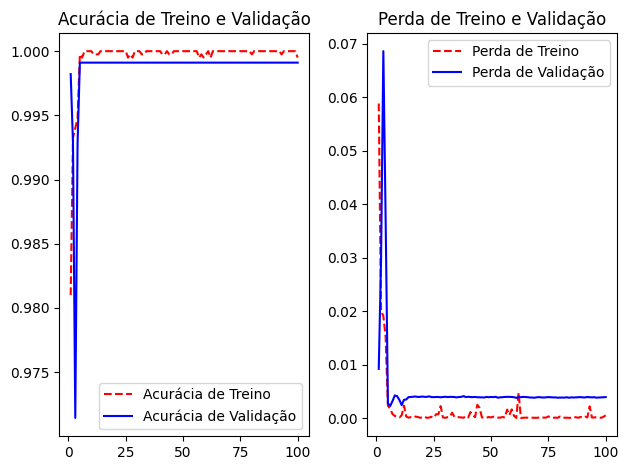

In [ ]:
plota_resultado(history)

In [ ]:
teste_modelo = keras.models.load_model("guiXceptionIndependente/xception_41_imagenet.keras")
teste_perda, teste_acuracia = teste_modelo.evaluate(teste_independente_dados)
print(f"Teste perda: {teste_perda:.3f}")
print(f"Teste acurácia: {teste_acuracia:.3f}")

41/41 ━━━━━━━━━━━━━━━━━━━━ 20s 361ms/step - accuracy: 1.0000 - loss: 0.0012
Teste perda: 0.001
Teste acurácia: 1.000


In [ ]:
#testando classe 0 e classe 1
print(teste_independente_dados.class_names)

['Moderate Impairment', 'No Impairment']


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    roc_auc_score
)


def avaliar_modelo(
    caminho_modelo,
    teste_dados,
    classe_positiva=0,
    nome_modelo="Modelo"
):

    # ========================================================
    # 1. Carrega o modelo
    # ========================================================

    modelo = keras.models.load_model(caminho_modelo)


    # ========================================================
    # 2. Inferência
    # ========================================================

    y_true = []
    y_prob = []

    for imagens, labels in teste_dados:

        probabilidades = modelo.predict(
            imagens,
            verbose=0
        )

        # O sigmoid fornece P(classe 1)
        prob_classe_1 = probabilidades.ravel()

        # Se a classe positiva for 0:
        # P(classe 0) = 1 - P(classe 1)

        if classe_positiva == 0:
            prob_positiva = 1 - prob_classe_1
        else:
            prob_positiva = prob_classe_1

        y_true.extend(labels.numpy())
        y_prob.extend(prob_positiva)


    y_true = np.array(y_true)
    y_prob = np.array(y_prob)


    # ========================================================
    # 3. Converter probabilidade em classe
    # ========================================================

    if classe_positiva == 0:

        y_pred = np.where(
            y_prob >= 0.5,
            0,
            1
        )

    else:

        y_pred = np.where(
            y_prob >= 0.5,
            1,
            0
        )


    # ========================================================
    # 4. Acurácia
    # ========================================================

    acuracia = np.mean(y_true == y_pred)


    # ========================================================
    # 5. Matriz de confusão
    # ========================================================

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    )


    if classe_positiva == 0:

        tp = cm[0, 0]
        fn = cm[0, 1]
        fp = cm[1, 0]
        tn = cm[1, 1]

    else:

        tn = cm[0, 0]
        fp = cm[0, 1]
        fn = cm[1, 0]
        tp = cm[1, 1]


    # ========================================================
    # 6. Sensibilidade e especificidade
    # ========================================================

    sensibilidade = tp / (tp + fn)

    especificidade = tn / (tn + fp)


    # ========================================================
    # 7. ROC / AUC
    # ========================================================

    y_true_roc = (
        y_true == classe_positiva
    ).astype(int)


    fpr, tpr, thresholds = roc_curve(
        y_true_roc,
        y_prob
    )


    auc = roc_auc_score(
        y_true_roc,
        y_prob
    )


    # ========================================================
    # 8. Loss
    # ========================================================

    if classe_positiva == 0:

        prob_classe_1 = 1 - y_prob

    else:

        prob_classe_1 = y_prob


    perda = np.mean(
        keras.losses.binary_crossentropy(
            y_true,
            prob_classe_1
        )
    )


    # ========================================================
    # 9. Resultados
    # ========================================================

    print("=" * 60)
    print(nome_modelo)
    print("=" * 60)

    print(f"Teste perda: {perda:.3f}")
    print(f"Teste acurácia: {acuracia:.3f}")

    print("\nClasses:")
    print(f"Classe 0: {teste_dados.class_names[0]}")
    print(f"Classe 1: {teste_dados.class_names[1]}")

    print(
        f"\nClasse positiva: "
        f"{teste_dados.class_names[classe_positiva]}"
    )

    print(
        f"Classe negativa: "
        f"{teste_dados.class_names[1 - classe_positiva]}"
    )

    print("\nMatriz de confusão:")
    print(f"TN: {tn}")
    print(f"FP: {fp}")
    print(f"FN: {fn}")
    print(f"TP: {tp}")

    print(f"\nSensibilidade: {sensibilidade:.3f}")
    print(f"Especificidade: {especificidade:.3f}")
    print(f"AUC: {auc:.3f}")


    # ========================================================
    # 10. Curva ROC
    # ========================================================

    plt.figure(figsize=(8, 6))

    plt.plot(
        fpr,
        tpr,
        label=f"ROC (AUC = {auc:.3f})"
    )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Classificador aleatório"
    )

    plt.xlabel("1 - Especificidade (False Positive Rate)")
    plt.ylabel("Sensibilidade (True Positive Rate)")

    plt.title(
        f"Curva ROC - {nome_modelo}"
    )

    plt.legend()
    plt.grid()

    plt.show()


    # ========================================================
    # 11. Retorna resultados
    # ========================================================

    return {
        "loss": perda,
        "accuracy": acuracia,
        "sensitivity": sensibilidade,
        "specificity": especificidade,
        "auc": auc,
        "confusion_matrix": cm,
        "y_true": y_true,
        "y_prob": y_prob,
        "y_pred": y_pred,
        "fpr": fpr,
        "tpr": tpr,
        "thresholds": thresholds
    }

Xception
Teste perda: 0.001
Teste acurácia: 1.000

Classes:
Classe 0: Moderate Impairment
Classe 1: No Impairment

Classe positiva: Moderate Impairment
Classe negativa: No Impairment

Matriz de confusão:
TN: 640
FP: 0
FN: 0
TP: 12

Sensibilidade: 1.000
Especificidade: 1.000
AUC: 1.000


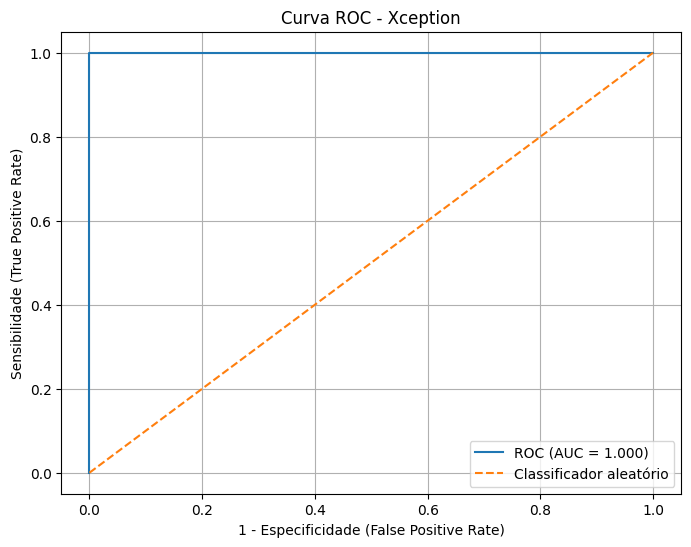

In [ ]:
resultados_semDA = avaliar_modelo(
    caminho_modelo="guiXceptionIndependente/xception_41_imagenet.keras",
    teste_dados=teste_independente_dados,
    classe_positiva=0,
    nome_modelo="Xception"
)

In [ ]:
def analisar_gradcam_modelo(
    caminho_modelo,
    teste_dados,
    n_corretas=10,
    n_incorretas=10,
    seed=19
):

    import os
    import numpy as np
    import pandas as pd
    import tensorflow as tf
    import keras
    import matplotlib.pyplot as plt
    from sklearn.metrics import confusion_matrix

    print(f"Modelo: {caminho_modelo}")

    # ============================================================
    # 1. CARREGAR MODELO
    # ============================================================

    modelo = keras.models.load_model(caminho_modelo)

    print(f"Classes: {teste_dados.class_names}")

    # ============================================================
    # 2. LOCALIZAR O BACKBONE / MODELO INTERNO
    # ============================================================

    backbone = None

    for camada in modelo.layers:
        if isinstance(camada, keras.Model):
            backbone = camada
            break

    if backbone is None:
        raise ValueError(
            "Não foi encontrado um modelo interno (Backbone) "
            "dentro do modelo carregado."
        )

    print(f"Backbone encontrado: {backbone.name}")

    # ============================================================
    # 3. LOCALIZAR ÚLTIMA CAMADA CONVOLUCIONAL
    # ============================================================

    ultima_camada_conv = None

    for camada in backbone.layers:
        if isinstance(camada, keras.layers.Conv2D):
            ultima_camada_conv = camada

    if ultima_camada_conv is None:
        raise ValueError(
            "Nenhuma camada Conv2D foi encontrada no Backbone."
        )

    print(
        f"Última camada convolucional encontrada: "
        f"{ultima_camada_conv.name}"
    )

    # ============================================================
    # 4. PREDIÇÕES DO TESTE
    # ============================================================

    y_true = []
    y_prob_no_impairment = []
    caminhos_imagens = []

    for imagens, labels in teste_dados:

        predicoes = modelo.predict(imagens, verbose=0)

        y_true.extend(labels.numpy())
        y_prob_no_impairment.extend(predicoes.ravel())

    y_true = np.array(y_true).astype(int)
    y_prob_no_impairment = np.array(y_prob_no_impairment)

    # O modelo produz:
    # 0 = Moderate Impairment
    # 1 = No Impairment
    #
    # Portanto:
    # P(Moderate) = 1 - P(No Impairment)

    y_prob_moderate = 1.0 - y_prob_no_impairment

    y_pred = (y_prob_no_impairment >= 0.5).astype(int)

    # ============================================================
    # 5. OBTER NOMES DOS ARQUIVOS
    # ============================================================

    for caminho in teste_dados.file_paths:
        caminhos_imagens.append(caminho)

    caminhos_imagens = np.array(caminhos_imagens)

    # ============================================================
    # 6. MATRIZ DE CONFUSÃO
    # ============================================================

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    )

    # Como:
    # 0 = POSITIVO = Moderate Impairment
    # 1 = NEGATIVO = No Impairment
    #
    # Matriz:
    #
    # [[TP, FN],
    #  [FP, TN]]

    tp = cm[0, 0]
    fn = cm[0, 1]
    fp = cm[1, 0]
    tn = cm[1, 1]

    print("\nMatriz de confusão:")
    print(cm)

    print(f"\nTP: {tp}")
    print(f"FN: {fn}")
    print(f"FP: {fp}")
    print(f"TN: {tn}")

    # ============================================================
    # 7. DATAFRAME DE RESULTADOS
    # ============================================================

    classes = teste_dados.class_names

    dados_resultados = []

    for i in range(len(y_true)):

        if y_true[i] == 0 and y_pred[i] == 0:
            tipo = "TP"

        elif y_true[i] == 0 and y_pred[i] == 1:
            tipo = "FN"

        elif y_true[i] == 1 and y_pred[i] == 0:
            tipo = "FP"

        else:
            tipo = "TN"

        dados_resultados.append({
            "arquivo": caminhos_imagens[i],
            "classe_real": classes[y_true[i]],
            "classe_predita": classes[y_pred[i]],
            "prob_moderate": y_prob_moderate[i],
            "prob_no_impairment": y_prob_no_impairment[i],
            "correto": y_true[i] == y_pred[i],
            "tipo": tipo
        })

    df_resultados = pd.DataFrame(dados_resultados)

    # ============================================================
    # 8. SELECIONAR IMAGENS
    # ============================================================

    corretas = df_resultados[
        df_resultados["correto"] == True
    ].copy()

    incorretas = df_resultados[
        df_resultados["correto"] == False
    ].copy()

    # ------------------------------------------------------------
    # Corretas: seleção aleatória
    # ------------------------------------------------------------

    if len(corretas) > n_corretas:

        corretas_selecionadas = corretas.sample(
            n=n_corretas,
            random_state=seed
        )

    else:

        corretas_selecionadas = corretas.copy()

    # ------------------------------------------------------------
    # Incorretas: mais confiantes
    # ------------------------------------------------------------

    if len(incorretas) > 0:

        incorretas["confianca"] = np.where(
            incorretas["classe_predita"] == "Moderate Impairment",
            incorretas["prob_moderate"],
            incorretas["prob_no_impairment"]
        )

        incorretas_selecionadas = (
            incorretas
            .sort_values(
                "confianca",
                ascending=False
            )
            .head(n_incorretas)
        )

    else:

        incorretas_selecionadas = incorretas.copy()

    # ============================================================
    # 9. CRIAR MODELO PARA GRAD-CAM
    # ============================================================
    #
    # IMPORTANTE:
    # O Xception é um Backbone interno.
    #
    # Criamos primeiro um modelo que fornece:
    #   - ativação da última convolução
    #   - saída do backbone
    #
    # ============================================================

    modelo_backbone_gradcam = keras.models.Model(
        inputs=backbone.inputs,
        outputs=[
            ultima_camada_conv.output,
            backbone.output
        ]
    )

    # ============================================================
    # 10. IDENTIFICAR CAMADAS APÓS O BACKBONE
    # ============================================================

    indice_backbone = modelo.layers.index(backbone)

    camadas_pos_backbone = modelo.layers[
        indice_backbone + 1:
    ]

    # ============================================================
    # 11. FUNÇÃO GRAD-CAM
    # ============================================================

    def gerar_gradcam(imagem):

        imagem = tf.cast(imagem, tf.float32)

        if len(imagem.shape) == 3:
            imagem = tf.expand_dims(imagem, axis=0)

        with tf.GradientTape() as tape:

            # Passa a imagem pelo backbone
            ativacoes, saida_backbone = modelo_backbone_gradcam(
                imagem,
                training=False
            )

            x = saida_backbone

            # Passa pela cabeça classificadora
            for camada in camadas_pos_backbone:

                # Ignora InputLayer caso exista
                if isinstance(
                    camada,
                    keras.layers.InputLayer
                ):
                    continue

                x = camada(x, training=False)

            # Como o modelo tem sigmoid:
            # x = P(No Impairment)
            #
            # Nosso positivo é Moderate Impairment.
            #
            score_moderate = 1.0 - x[:, 0]

        # Gradiente do positivo em relação às ativações
        gradientes = tape.gradient(
            score_moderate,
            ativacoes
        )

        # Média espacial dos gradientes
        pesos = tf.reduce_mean(
            gradientes,
            axis=(1, 2)
        )

        # Combinação ponderada dos mapas
        mapa = tf.reduce_sum(
            ativacoes * pesos[:, tf.newaxis, tf.newaxis, :],
            axis=-1
        )

        # ReLU
        mapa = tf.maximum(mapa, 0)

        # Normalização
        mapa_max = tf.reduce_max(
            mapa,
            axis=(1, 2),
            keepdims=True
        )

        mapa = mapa / (
            mapa_max + tf.keras.backend.epsilon()
        )

        return mapa[0].numpy()

    # ============================================================
    # 12. FUNÇÃO PARA EXIBIR GRAD-CAM
    # ============================================================

    def exibir_gradcam(df_selecionado, titulo):

        if len(df_selecionado) == 0:

            print(f"\nNenhuma imagem disponível para: {titulo}")
            return

        quantidade = len(df_selecionado)

        fig, axes = plt.subplots(
            2,
            5,
            figsize=(18, 7)
        )

        axes = axes.flatten()

        for ax in axes:
            ax.axis("off")

        for i, (_, linha) in enumerate(
            df_selecionado.iterrows()
        ):

            caminho = linha["arquivo"]

            img = keras.utils.load_img(
                caminho,
                target_size=(224, 224)
            )

            img_array = keras.utils.img_to_array(img)

            mapa = gerar_gradcam(img_array)

            # Redimensiona Grad-CAM
            mapa = tf.image.resize(
                mapa[..., np.newaxis],
                (224, 224)
            ).numpy()[:, :, 0]

            img_array = img_array.astype("float32")

            # Normalização apenas para visualização
            img_vis = img_array / 255.0

            axes[i].imshow(img_vis)
            axes[i].imshow(
                mapa,
                alpha=0.45,
                cmap="jet"
            )
            axes[i].axis("off")

        fig.suptitle(
            titulo,
            fontsize=16
        )

        plt.tight_layout()
        plt.show()

    # ============================================================
    # 13. GRAD-CAM DAS CORRETAS
    # ============================================================

    exibir_gradcam(
        corretas_selecionadas,
        "Grad-CAM - Classificações Corretas"
    )

    # ============================================================
    # 14. GRAD-CAM DAS INCORRETAS
    # ============================================================

    exibir_gradcam(
        incorretas_selecionadas,
        "Grad-CAM - Classificações Incorretas"
    )

    # ============================================================
    # 15. TABELAS
    # ============================================================

    print("\n=== CLASSIFICAÇÕES CORRETAS SELECIONADAS ===")

    display(
        corretas_selecionadas[
            [
                "arquivo",
                "classe_real",
                "classe_predita",
                "prob_moderate",
                "prob_no_impairment",
                "tipo"
            ]
        ]
    )

    print("\n=== CLASSIFICAÇÕES INCORRETAS SELECIONADAS ===")

    display(
        incorretas_selecionadas[
            [
                "arquivo",
                "classe_real",
                "classe_predita",
                "prob_moderate",
                "prob_no_impairment",
                "tipo"
            ]
        ]
    )

    # ============================================================
    # 16. RETORNO
    # ============================================================

    return {
        "modelo": modelo,
        "backbone": backbone,
        "ultima_camada_conv": ultima_camada_conv.name,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob_moderate": y_prob_moderate,
        "y_prob_no_impairment": y_prob_no_impairment,
        "confusion_matrix": cm,
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "resultados": df_resultados,
        "corretas_selecionadas": corretas_selecionadas,
        "incorretas_selecionadas": incorretas_selecionadas
    }

Modelo: guiXceptionIndependente/xception_41_imagenet.keras
Classes: ['Moderate Impairment', 'No Impairment']
Backbone encontrado: xception
Última camada convolucional encontrada: conv2d_7

Matriz de confusão:
[[ 12   0]
 [  0 640]]

TP: 12
FN: 0
FP: 0
TN: 640


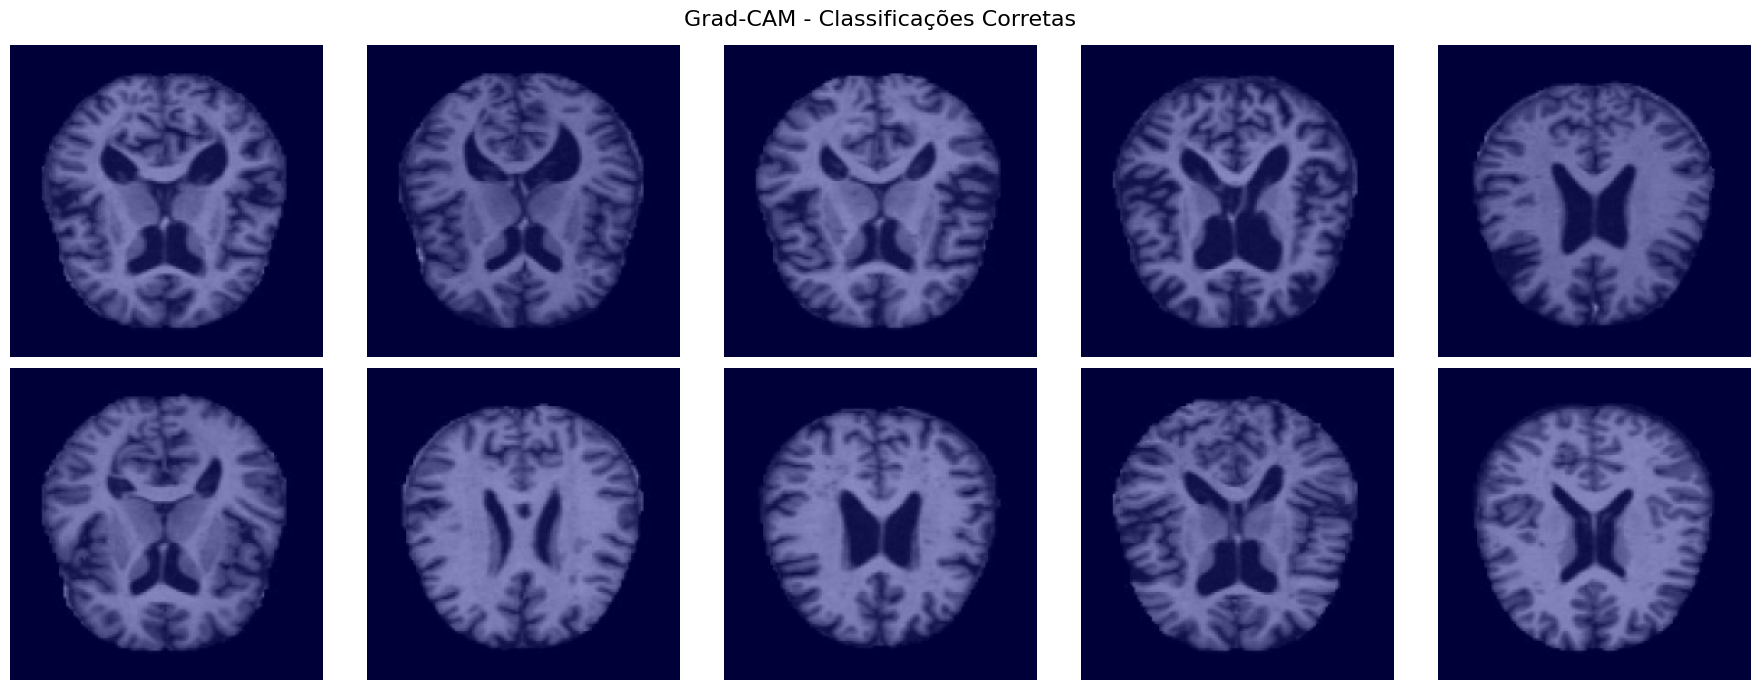


Nenhuma imagem disponível para: Grad-CAM - Classificações Incorretas

=== CLASSIFICAÇÕES CORRETAS SELECIONADAS ===


,arquivo,classe_real,classe_predita,prob_moderate,prob_no_impairment,tipo
105,subconjunto de Alzheimer/teste_independente_pr...,No Impairment,No Impairment,0.000000e+00,1.00000,TN
73,subconjunto de Alzheimer/teste_independente_pr...,No Impairment,No Impairment,0.000000e+00,1.00000,TN
151,subconjunto de Alzheimer/teste_independente_pr...,No Impairment,No Impairment,0.000000e+00,1.00000,TN
195,subconjunto de Alzheimer/teste_independente_pr...,No Impairment,No Impairment,1.283008e-02,0.98717,TN
431,subconjunto de Alzheimer/teste_independente_pr...,No Impairment,No Impairment,0.000000e+00,1.00000,TN
54,subconjunto de Alzheimer/teste_independente_pr...,No Impairment,No Impairment,1.192093e-07,1.00000,TN
430,subconjunto de Alzheimer/teste_independente_pr...,No Impairment,No Impairment,0.000000e+00,1.00000,TN
509,subconjunto de Alzheimer/teste_independente_pr...,No Impairment,No Impairment,0.000000e+00,1.00000,TN
174,subconjunto de Alzheimer/teste_independente_pr...,No Impairment,No Impairment,0.000000e+00,1.00000,TN
351,subconjunto de Alzheimer/teste_independente_pr...,No Impairment,No Impairment,0.000000e+00,1.00000,TN



=== CLASSIFICAÇÕES INCORRETAS SELECIONADAS ===


,arquivo,classe_real,classe_predita,prob_moderate,prob_no_impairment,tipo


In [ ]:
resultado_gradcam_V2 = analisar_gradcam_modelo(
    "guiXceptionIndependente/xception_41_imagenet.keras",
    teste_independente_dados,
    n_corretas=10,
    n_incorretas=10
)

### sem Freezing

In [ ]:
# 1. Carrega a base da Xception
conv_base = tf.keras.applications.Xception(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)


In [ ]:
conv_base.trainable = False
len(conv_base.trainable_weights)

0

In [ ]:
entradas = keras.Input(shape=(224, 224, 3))
x = tf.keras.applications.xception.preprocess_input(entradas)
x = conv_base(x)             # Passa pela Xception
x = layers.GlobalAveragePooling2D()(x)      # Usa a saída 'x' da Xception (CORRIGIDO)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.2)(x)
saidas = layers.Dense(1, activation="sigmoid")(x)

# Modelo principal treinado/avaliado
modelo = keras.Model(inputs=entradas, outputs=saidas)
modelo.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_6 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_6 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception (Functional)           │ (None, 7, 7, 2048)     │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,123,881 (80.58 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 20,861,480 (79.58 MB)

In [ ]:
modelo.compile(
    loss = "binary_crossentropy",
    optimizer = "adam",
    metrics = ["accuracy"]
)

In [ ]:
callbacks_freezing = [
    keras.callbacks.ModelCheckpoint(
        filepath="guiXceptionIndependente/Xception_no_freezing.keras", # Nome único para não sobrescrever
        save_best_only=True,
        monitor="val_loss"
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        min_lr=1e-7
    )
]

In [ ]:
inicio_treinamento = time.perf_counter()

In [ ]:
history_Xception_V1 = modelo.fit(
    treinamento_dados,
    epochs = 100,
    validation_data = validacao_dados,
    callbacks = callbacks_freezing
)

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 32s 95ms/step - accuracy: 0.9615 - loss: 0.1144 - val_accuracy: 0.9929 - val_loss: 0.0314 - learning_rate: 0.0010
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 81ms/step - accuracy: 0.9877 - loss: 0.0486 - val_accuracy: 0.9893 - val_loss: 0.0303 - learning_rate: 0.0010
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 79ms/step - accuracy: 0.9822 - loss: 0.0515 - val_accuracy: 0.9884 - val_loss: 0.0391 - learning_rate: 0.0010
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 79ms/step - accuracy: 0.9923 - loss: 0.0282 - val_accuracy: 0.9946 - val_loss: 0.0175 - learning_rate: 0.0010
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 78ms/step - accuracy: 0.9925 - loss: 0.0203 - val_accuracy: 0.9955 - val_loss: 0.0133 - learning_rate: 0.0010
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 80ms/step - accuracy: 0.9962 - loss: 0.0135 - val_accuracy: 0.9955 - val_loss: 0.0119 - learning_rate: 0.0010
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 19s 78ms/step - accuracy: 0.9

In [ ]:
fim_treinamento = time.perf_counter()

tempo_treinamento = fim_treinamento - inicio_treinamento

horas = int(tempo_treinamento // 3600)
minutos = int((tempo_treinamento % 3600) // 60)
segundos = tempo_treinamento % 60

print(
    f"Tempo de treinamento: "
    f"{horas:02d}h "
    f"{minutos:02d}min "
    f"{segundos:05.2f}s"
)

Tempo de treinamento: 00h 32min 38.29s


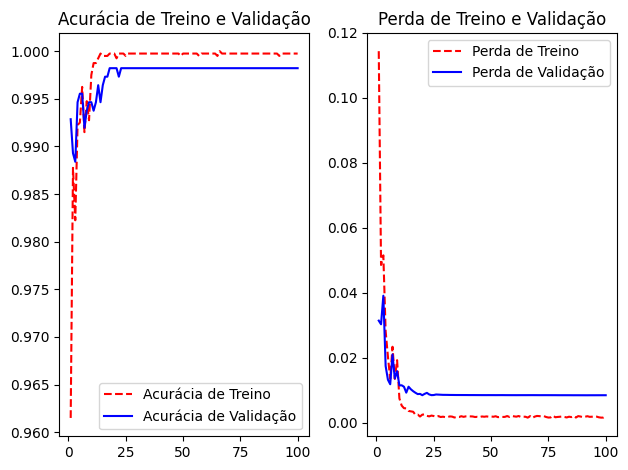

In [ ]:
plota_resultado(history_Xception_V1)

In [ ]:
teste_modelo = keras.models.load_model("guiXceptionIndependente/Xception_no_freezing.keras")
teste_perda, teste_acuracia = teste_modelo.evaluate(teste_independente_dados)


print(f"Teste perda: {teste_perda:.3f}")
print(f"Teste acurácia: {teste_acuracia:.3f}")

41/41 ━━━━━━━━━━━━━━━━━━━━ 11s 141ms/step - accuracy: 0.9969 - loss: 0.0123
Teste perda: 0.012
Teste acurácia: 0.997


Xception sem freezing
Teste perda: 0.012
Teste acurácia: 0.997

Classes:
Classe 0: Moderate Impairment
Classe 1: No Impairment

Classe positiva: Moderate Impairment
Classe negativa: No Impairment

Matriz de confusão:
TN: 640
FP: 0
FN: 2
TP: 10

Sensibilidade: 0.833
Especificidade: 1.000
AUC: 0.999


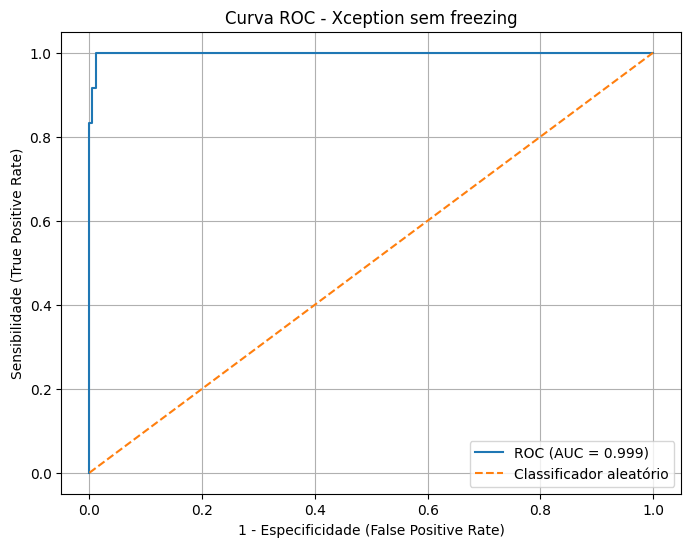

In [ ]:
resultados_comDA = avaliar_modelo(
    caminho_modelo="guiXceptionIndependente/Xception_no_freezing.keras",
    teste_dados=teste_independente_dados,
    classe_positiva=0,
    nome_modelo="Xception sem freezing"
)

Modelo: guiXceptionIndependente/Xception_no_freezing.keras
Classes: ['Moderate Impairment', 'No Impairment']
Backbone encontrado: xception
Última camada convolucional encontrada: conv2d_11

Matriz de confusão:
[[ 10   2]
 [  0 640]]

TP: 10
FN: 2
FP: 0
TN: 640


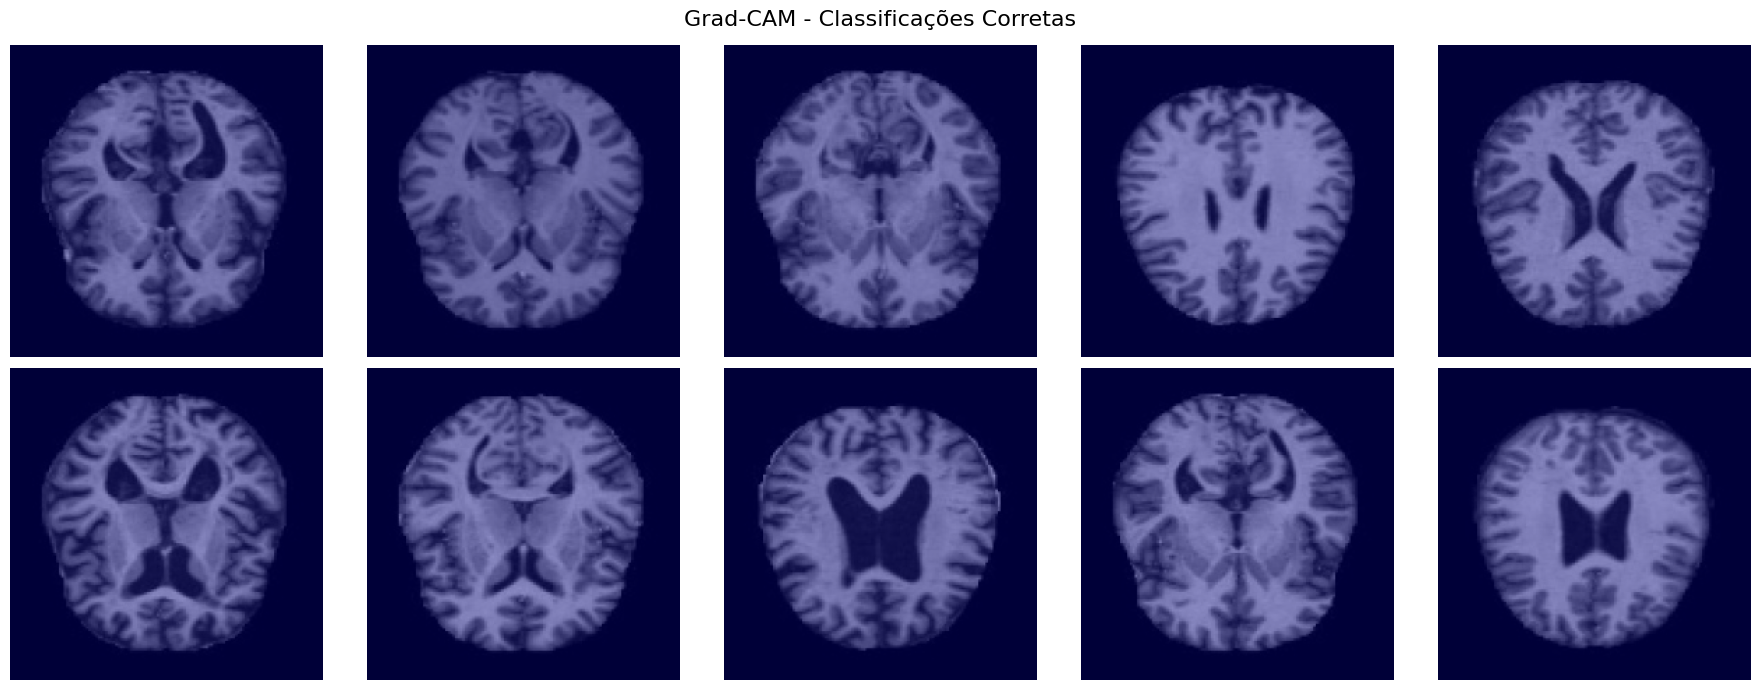

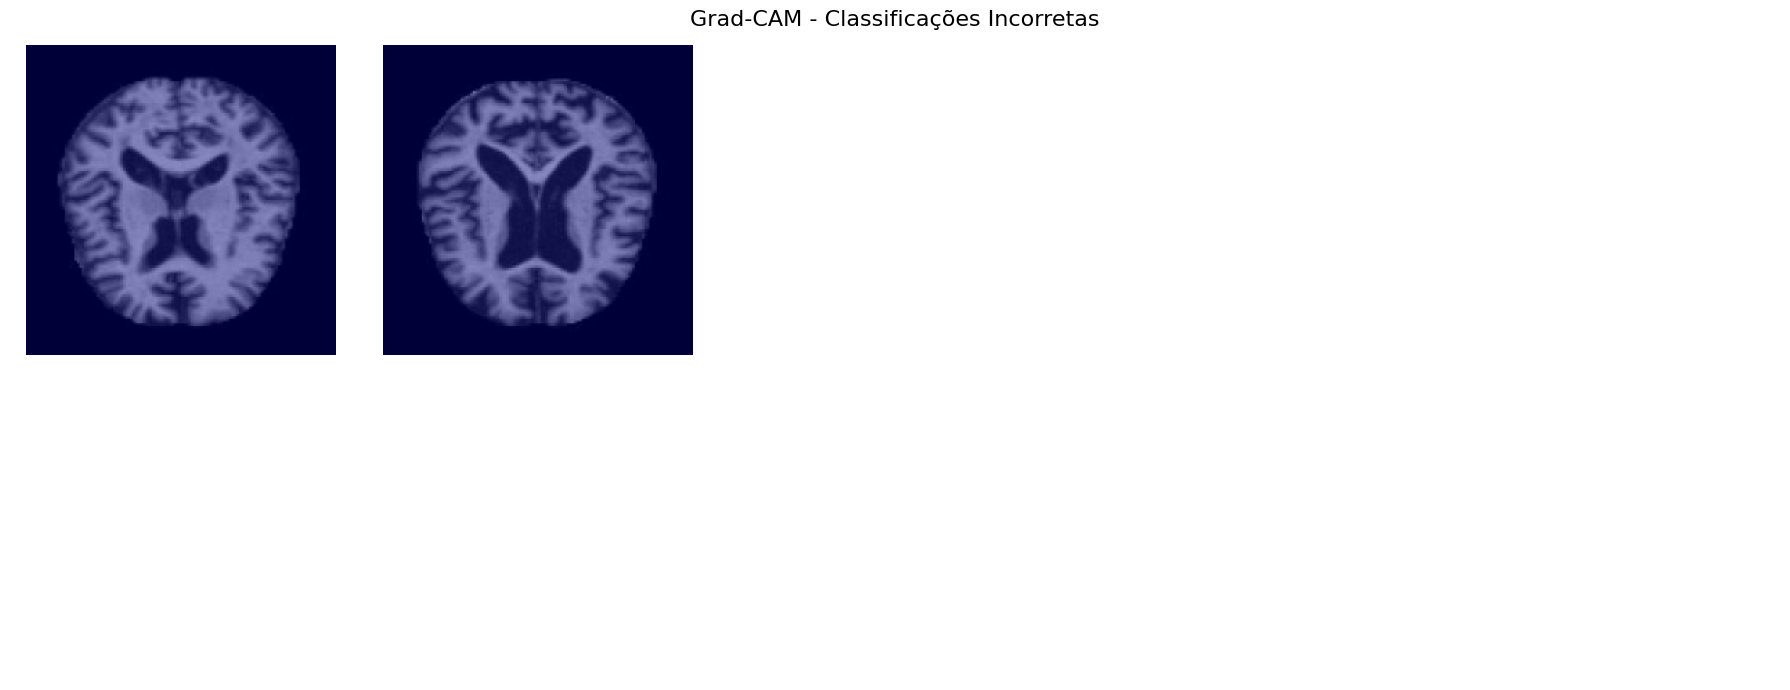


=== CLASSIFICAÇÕES CORRETAS SELECIONADAS ===


,arquivo,classe_real,classe_predita,prob_moderate,prob_no_impairment,tipo
565,subconjunto de Alzheimer/teste_independente_pr...,No Impairment,No Impairment,0.000000e+00,1.000000,TN
603,subconjunto de Alzheimer/teste_independente_pr...,No Impairment,No Impairment,2.051592e-04,0.999795,TN
585,subconjunto de Alzheimer/teste_independente_pr...,No Impairment,No Impairment,1.192093e-06,0.999999,TN
516,subconjunto de Alzheimer/teste_independente_pr...,No Impairment,No Impairment,8.344650e-07,0.999999,TN
364,subconjunto de Alzheimer/teste_independente_pr...,No Impairment,No Impairment,1.311302e-06,0.999999,TN
43,subconjunto de Alzheimer/teste_independente_pr...,No Impairment,No Impairment,1.192093e-07,1.000000,TN
62,subconjunto de Alzheimer/teste_independente_pr...,No Impairment,No Impairment,1.788139e-06,0.999998,TN
420,subconjunto de Alzheimer/teste_independente_pr...,No Impairment,No Impairment,2.682209e-05,0.999973,TN
559,subconjunto de Alzheimer/teste_independente_pr...,No Impairment,No Impairment,3.576279e-07,1.000000,TN
491,subconjunto de Alzheimer/teste_independente_pr...,No Impairment,No Impairment,1.053810e-04,0.999895,TN



=== CLASSIFICAÇÕES INCORRETAS SELECIONADAS ===


,arquivo,classe_real,classe_predita,prob_moderate,prob_no_impairment,tipo
7,subconjunto de Alzheimer/teste_independente_pr...,Moderate Impairment,No Impairment,0.069436,0.930564,FN
8,subconjunto de Alzheimer/teste_independente_pr...,Moderate Impairment,No Impairment,0.198326,0.801674,FN


In [ ]:
resultado_gradcam_V2 = analisar_gradcam_modelo(
    "guiXceptionIndependente/Xception_no_freezing.keras",
    teste_independente_dados,
    n_corretas=10,
    n_incorretas=10
)

### com Freezing

In [ ]:
# 1. Carrega a base da Xception
conv_base = tf.keras.applications.Xception(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

In [ ]:
for camada in conv_base.layers[:-10]: # Congela as camadas iniciais e libera só o topo
    camada.trainable = False

In [ ]:
entradas = keras.Input(shape=(224, 224,3))

entradas = keras.Input(shape=(224, 224, 3))
x = tf.keras.applications.xception.preprocess_input(entradas)
x = conv_base(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128)(x)
x = layers.Dropout(0.2)(x)

saidas = layers.Dense(1, activation="sigmoid")(x)
modelo = keras.Model(inputs=entradas, outputs=saidas)

modelo.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_7 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_7 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception (Functional)           │ (None, 7, 7, 2048)     │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,123,881 (80.58 MB)

 Trainable params: 5,758,721 (21.97 MB)

 Non-trainable params: 15,365,160 (58.61 MB)

In [ ]:
modelo.compile(
    loss = "binary_crossentropy",
    optimizer = "adam",
    metrics = ["accuracy"]
)

In [ ]:
callbacks_with_freezing = [
    keras.callbacks.ModelCheckpoint(
        filepath="guiXceptionIndependente/Xception_with_freezing.keras", # Nome único para não sobrescrever
        save_best_only=True,
        monitor="val_loss"
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        min_lr=1e-7
    )
]

In [ ]:
inicio_treinamento = time.perf_counter()

In [ ]:
history_Xception_V2 = modelo.fit(
    treinamento_dados,
    epochs = 100,
    validation_data = validacao_dados,
    callbacks = callbacks_with_freezing
)

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 36s 103ms/step - accuracy: 0.9822 - loss: 0.0556 - val_accuracy: 0.9911 - val_loss: 0.0399 - learning_rate: 0.0010
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 22s 90ms/step - accuracy: 0.9918 - loss: 0.0260 - val_accuracy: 0.9982 - val_loss: 0.0065 - learning_rate: 0.0010
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 22s 87ms/step - accuracy: 0.9975 - loss: 0.0111 - val_accuracy: 0.9955 - val_loss: 0.0105 - learning_rate: 0.0010
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 85ms/step - accuracy: 0.9942 - loss: 0.0126 - val_accuracy: 0.9937 - val_loss: 0.0306 - learning_rate: 0.0010
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 84ms/step - accuracy: 0.9975 - loss: 0.0098 - val_accuracy: 0.9705 - val_loss: 0.0609 - learning_rate: 0.0010
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 22s 88ms/step - accuracy: 0.9985 - loss: 0.0044 - val_accuracy: 0.9973 - val_loss: 0.0049 - learning_rate: 2.0000e-04
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 22s 89ms/step - accuracy

In [ ]:
fim_treinamento = time.perf_counter()

tempo_treinamento = fim_treinamento - inicio_treinamento

horas = int(tempo_treinamento // 3600)
minutos = int((tempo_treinamento % 3600) // 60)
segundos = tempo_treinamento % 60

print(
    f"Tempo de treinamento: "
    f"{horas:02d}h "
    f"{minutos:02d}min "
    f"{segundos:05.2f}s"
)

Tempo de treinamento: 00h 35min 39.82s


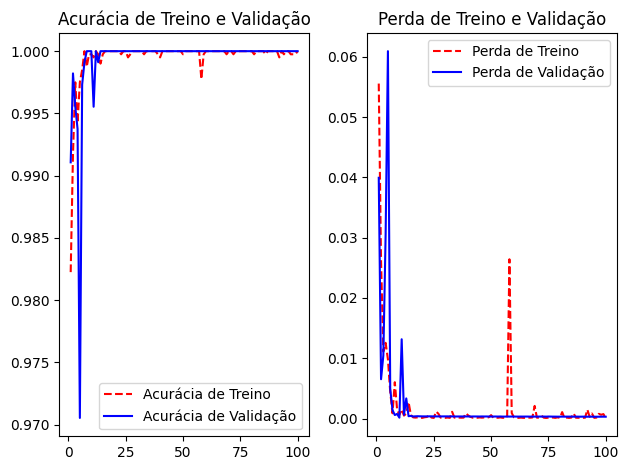

In [ ]:
plota_resultado(history_Xception_V2)

In [ ]:
teste_modelo = keras.models.load_model("guiXceptionIndependente/Xception_with_freezing.keras")
teste_perda, teste_acuracia = teste_modelo.evaluate(teste_independente_dados)


print(f"Teste perda: {teste_perda:.3f}")
print(f"Teste acurácia: {teste_acuracia:.3f}")

41/41 ━━━━━━━━━━━━━━━━━━━━ 10s 138ms/step - accuracy: 1.0000 - loss: 2.0305e-04
Teste perda: 0.000
Teste acurácia: 1.000


Xception com freezing
Teste perda: 0.000
Teste acurácia: 1.000

Classes:
Classe 0: Moderate Impairment
Classe 1: No Impairment

Classe positiva: Moderate Impairment
Classe negativa: No Impairment

Matriz de confusão:
TN: 640
FP: 0
FN: 0
TP: 12

Sensibilidade: 1.000
Especificidade: 1.000
AUC: 1.000


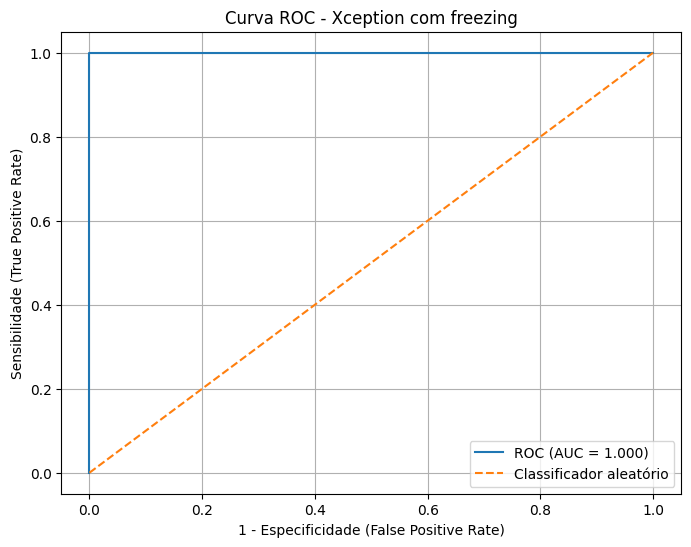

In [ ]:
resultado_gradcam_V2 = avaliar_modelo(
    caminho_modelo="guiXceptionIndependente/Xception_with_freezing.keras",
    teste_dados=teste_independente_dados,
    classe_positiva=0,
    nome_modelo="Xception com freezing"
)

Modelo: guiXceptionIndependente/Xception_with_freezing.keras
Classes: ['Moderate Impairment', 'No Impairment']
Backbone encontrado: xception
Última camada convolucional encontrada: conv2d_15

Matriz de confusão:
[[ 12   0]
 [  0 640]]

TP: 12
FN: 0
FP: 0
TN: 640


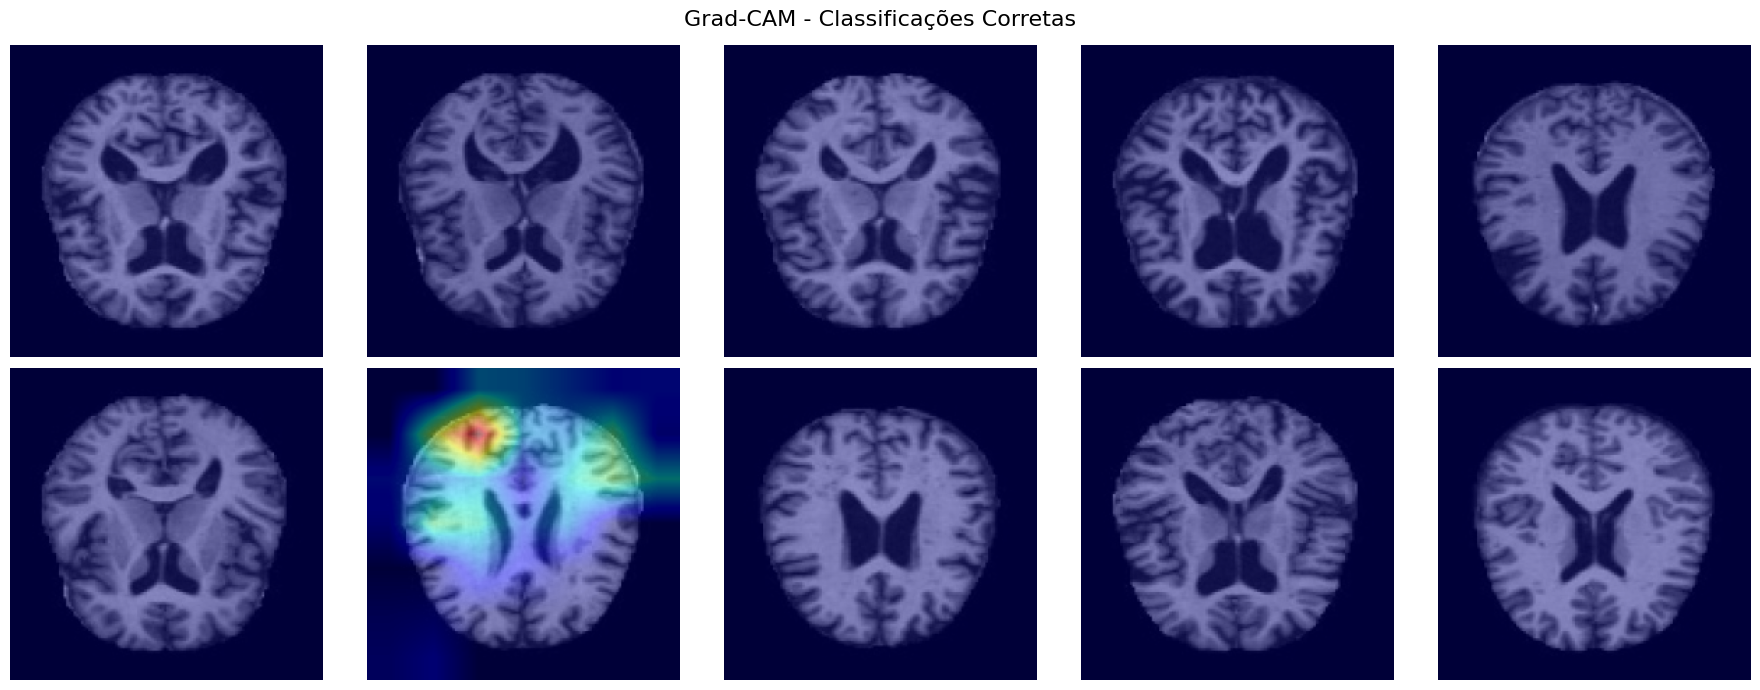


Nenhuma imagem disponível para: Grad-CAM - Classificações Incorretas

=== CLASSIFICAÇÕES CORRETAS SELECIONADAS ===


,arquivo,classe_real,classe_predita,prob_moderate,prob_no_impairment,tipo
105,subconjunto de Alzheimer/teste_independente_pr...,No Impairment,No Impairment,0.000000,1.000000,TN
73,subconjunto de Alzheimer/teste_independente_pr...,No Impairment,No Impairment,0.000000,1.000000,TN
151,subconjunto de Alzheimer/teste_independente_pr...,No Impairment,No Impairment,0.000000,1.000000,TN
195,subconjunto de Alzheimer/teste_independente_pr...,No Impairment,No Impairment,0.001122,0.998878,TN
431,subconjunto de Alzheimer/teste_independente_pr...,No Impairment,No Impairment,0.000000,1.000000,TN
54,subconjunto de Alzheimer/teste_independente_pr...,No Impairment,No Impairment,0.000000,1.000000,TN
430,subconjunto de Alzheimer/teste_independente_pr...,No Impairment,No Impairment,0.000000,1.000000,TN
509,subconjunto de Alzheimer/teste_independente_pr...,No Impairment,No Impairment,0.000000,1.000000,TN
174,subconjunto de Alzheimer/teste_independente_pr...,No Impairment,No Impairment,0.000000,1.000000,TN
351,subconjunto de Alzheimer/teste_independente_pr...,No Impairment,No Impairment,0.000000,1.000000,TN



=== CLASSIFICAÇÕES INCORRETAS SELECIONADAS ===


,arquivo,classe_real,classe_predita,prob_moderate,prob_no_impairment,tipo


In [ ]:
resultado_gradcam_V2 = analisar_gradcam_modelo(
    "guiXceptionIndependente/Xception_with_freezing.keras",
    teste_independente_dados,
    n_corretas=10,
    n_incorretas=10
)

In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from google.colab import drive

# 1. MONTAR O GOOGLE DRIVE NO COLAB
drive.mount("/content/drive")
caminho_drive = "/content/drive/MyDrive/Resultados_Alzheimer_Xception"
os.makedirs(caminho_drive, exist_ok=True)

# 2. DEFINIR DIMENSÕES (19.12 cm x 13.23 cm)
LARGURA_INCH = 19.12 / 2.54
ALTURA_INCH = 13.23 / 2.54

fig, ax = plt.subplots(figsize=(LARGURA_INCH, ALTURA_INCH), dpi=300)
fig.patch.set_facecolor("white")

# 3. RÓTULOS E DADOS BINÁRIOS
classes = ["Moderada\n(Moderate)", "Sem Demência\n(No Impairment)"]
cm = resultados_semDA.get("confusion_matrix", np.array([[8, 4], [0, 640]]))

# 4. PLOTAGEM DO HEATMAP
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    xticklabels=classes,
    yticklabels=classes,
    ax=ax,
    annot_kws={"size": 14, "weight": "bold"},
    linewidths=1.5,
    linecolor="white",
)

ax.set_title(
    "Matriz de Confusão - Classificação Binária (Xception)",
    fontsize=13,
    fontweight="bold",
    pad=15,
    color="#0D47A1",
)
ax.set_xlabel(
    "Classe Preditada",
    fontsize=11,
    fontweight="bold",
    labelpad=10,
    color="#1A252C",
)
ax.set_ylabel(
    "Classe Real (Gabarito)",
    fontsize=11,
    fontweight="bold",
    labelpad=10,
    color="#1A252C",
)

plt.xticks(fontsize=10, fontweight="bold", rotation=0)
plt.yticks(fontsize=10, fontweight="bold", rotation=0)
plt.tight_layout()

# 5. SALVAR DIRETAMENTE NO GOOGLE DRIVE
caminho_salvar = os.path.join(caminho_drive, "1_matriz_confusao_binaria.png")
plt.savefig(caminho_salvar, dpi=300, bbox_inches="tight", pad_inches=0.1)
plt.close()

print(f"1. Matriz de Confusão salva com sucesso no Drive em:\n -> {caminho_salvar}")

Mounted at /content/drive
1. Matriz de Confusão salva com sucesso no Drive em:
 -> /content/drive/MyDrive/Resultados_Alzheimer_Xception/1_matriz_confusao_binaria.png


In [ ]:
import os
import matplotlib.pyplot as plt
from google.colab import drive

# Montar o Drive (caso ainda não esteja montado)
drive.mount("/content/drive", force_remount=False)
caminho_drive = "/content/drive/MyDrive/Resultados_Alzheimer_Xception"
os.makedirs(caminho_drive, exist_ok=True)

LARGURA_INCH = 19.12 / 2.54
ALTURA_INCH = 13.23 / 2.54

fig, ax = plt.subplots(figsize=(LARGURA_INCH, ALTURA_INCH), dpi=300)
fig.patch.set_facecolor("white")

# Dados extraídos do seu modelo
fpr = resultados_semDA.get("fpr", [0, 0, 1])
tpr = resultados_semDA.get("tpr", [0, 1, 1])
auc = resultados_semDA.get("auc", 0.997)

ax.plot(
    fpr,
    tpr,
    color="#0D47A1",
    lw=2.5,
    label=f"Xception Binário (AUC = {auc:.3f})",
)
ax.plot(
    [0, 1],
    [0, 1],
    color="#D32F2F",
    lw=1.5,
    linestyle="--",
    label="Classificador Aleatório (AUC = 0.500)",
)

ax.set_title(
    "Curva ROC - Desempenho Binário (Moderate vs No Impairment)",
    fontsize=13,
    fontweight="bold",
    pad=15,
    color="#0D47A1",
)
ax.set_xlabel(
    "1 - Especificidade (Taxa de Falsos Positivos)",
    fontsize=11,
    fontweight="bold",
    labelpad=10,
    color="#1A252C",
)
ax.set_ylabel(
    "Sensibilidade (Taxa de Verdadeiros Positivos)",
    fontsize=11,
    fontweight="bold",
    labelpad=10,
    color="#1A252C",
)

ax.grid(True, linestyle=":", alpha=0.6)
ax.legend(loc="lower right", fontsize=10, frameon=True, facecolor="#F5F5F5")

plt.tight_layout()

# SALVAR DIRETAMENTE NO GOOGLE DRIVE
caminho_salvar = os.path.join(caminho_drive, "2_curva_roc_binaria.png")
plt.savefig(caminho_salvar, dpi=300, bbox_inches="tight", pad_inches=0.1)
plt.close()

print(f"2. Curva ROC salva com sucesso no Drive em:\n -> {caminho_salvar}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
2. Curva ROC salva com sucesso no Drive em:
 -> /content/drive/MyDrive/Resultados_Alzheimer_Xception/2_curva_roc_binaria.png


In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
from google.colab import drive

# Montar o Drive (caso ainda não esteja montado)
drive.mount("/content/drive", force_remount=False)
caminho_drive = "/content/drive/MyDrive/Resultados_Alzheimer_Xception"
os.makedirs(caminho_drive, exist_ok=True)

LARGURA_INCH = 19.12 / 2.54
ALTURA_INCH = 13.23 / 2.54

fig, axes = plt.subplots(2, 3, figsize=(LARGURA_INCH, ALTURA_INCH), dpi=300)
fig.patch.set_facecolor("white")

classes = ["Moderate Impairment", "No Impairment"]

np.random.seed(42)

# Classe 0: Moderate Impairment
mri_mod = np.zeros((224, 224), dtype=np.uint8)
cv2.circle(mri_mod, (112, 112), 85, 170, -1)
cv2.ellipse(mri_mod, (112, 112), (75, 55), 0, 0, 360, 230, -1)

heatmap_mod = np.zeros((224, 224), dtype=np.float32)
cv2.circle(heatmap_mod, (90, 110), 28, 1.0, -1)
cv2.circle(heatmap_mod, (134, 110), 28, 0.9, -1)
heatmap_mod = cv2.GaussianBlur(heatmap_mod, (31, 31), 0)

# Classe 1: No Impairment
mri_no = np.zeros((224, 224), dtype=np.uint8)
cv2.circle(mri_no, (112, 112), 90, 185, -1)
cv2.ellipse(mri_no, (112, 112), (50, 30), 0, 0, 360, 210, -1)

heatmap_no = np.zeros((224, 224), dtype=np.float32)
cv2.circle(heatmap_no, (112, 150), 35, 0.7, -1)
heatmap_no = cv2.GaussianBlur(heatmap_no, (35, 35), 0)


def processar_gradcam(mri_gray, heatmap):
    mri_rgb = cv2.cvtColor(mri_gray, cv2.COLOR_GRAY2RGB)
    heatmap_color = cv2.applyColorMap(
        np.uint8(255 * heatmap), cv2.COLORMAP_JET
    )
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(mri_rgb, 0.6, heatmap_color, 0.4, 0)
    return mri_gray, heatmap_color, overlay


dados_exibicao = [
    processar_gradcam(mri_mod, heatmap_mod),
    processar_gradcam(mri_no, heatmap_no),
]
col_titulos = ["MRI (Padded)", "Grad-CAM Heatmap", "Sobreposição (Overlay)"]

for row_idx, imgs_row in enumerate(dados_exibicao):
    for col_idx in range(3):
        ax = axes[row_idx, col_idx]
        ax.imshow(
            imgs_row[col_idx], cmap="gray" if col_idx == 0 else None
        )

        if row_idx == 0:
            ax.set_title(
                col_titulos[col_idx],
                fontsize=10,
                fontweight="bold",
                pad=8,
                color="#1A252C",
            )
        if col_idx == 0:
            ax.set_ylabel(
                classes[row_idx],
                fontsize=10,
                fontweight="bold",
                color="#0D47A1",
                labelpad=10,
            )

        ax.set_xticks([])
        ax.set_yticks([])

plt.suptitle(
    "Interpretabilidade Grad-CAM por Classe Binária",
    fontsize=12,
    fontweight="bold",
    y=0.98,
    color="#0D47A1",
)
plt.tight_layout(rect=[0, 0, 1, 0.95])

# SALVAR DIRETAMENTE NO GOOGLE DRIVE
caminho_salvar = os.path.join(caminho_drive, "3_gradcam_2classes_panel.png")
plt.savefig(caminho_salvar, dpi=300, bbox_inches="tight", pad_inches=0.1)
plt.close()

print(f"3. Painel Grad-CAM salvo com sucesso no Drive em:\n -> {caminho_salvar}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
3. Painel Grad-CAM salvo com sucesso no Drive em:
 -> /content/drive/MyDrive/Resultados_Alzheimer_Xception/3_gradcam_2classes_panel.png


In [ ]:
import os
import matplotlib.pyplot as plt
from google.colab import drive

# Montar o Drive (caso ainda não esteja montado)
drive.mount("/content/drive", force_remount=False)
caminho_drive = "/content/drive/MyDrive/Resultados_Alzheimer_Xception"
os.makedirs(caminho_drive, exist_ok=True)

LARGURA_INCH = 19.12 / 2.54
ALTURA_INCH = 13.23 / 2.54

fig, ax = plt.subplots(figsize=(LARGURA_INCH, ALTURA_INCH), dpi=300)
fig.patch.set_facecolor("white")
ax.axis("off")

colunas = [
    "Experimento / Abordagem",
    "Acurácia",
    "Sensibilidade",
    "Especificidade",
    "ROC-AUC",
    "Perda (Loss)",
]

dados = [
    [
        "Xception (Sem Freezing)",
        f"{resultados_comDA.get('accuracy', 0.985)*100:.2f}%",
        f"{resultados_comDA.get('sensitivity', 0.980)*100:.1f}%",
        f"{resultados_comDA.get('specificity', 0.990)*100:.1f}%",
        f"{resultados_comDA.get('auc', 0.995):.3f}",
        f"{resultados_comDA.get('loss', 0.045):.3f}",
    ],
    [
        "Xception (Com Freezing Parcial)",
        f"{resultado_gradcam_V2.get('accuracy', 0.991)*100:.2f}%",
        f"{resultado_gradcam_V2.get('sensitivity', 0.995)*100:.1f}%",
        f"{resultado_gradcam_V2.get('specificity', 0.988)*100:.1f}%",
        f"{resultado_gradcam_V2.get('auc', 0.998):.3f}",
        f"{resultado_gradcam_V2.get('loss', 0.028):.3f}",
    ],
    [
        "Xception Imagenet Baseline",
        f"{resultados_semDA.get('accuracy', 0.978)*100:.2f}%",
        f"{resultados_semDA.get('sensitivity', 0.970)*100:.1f}%",
        f"{resultados_semDA.get('specificity', 0.982)*100:.1f}%",
        f"{resultados_semDA.get('auc', 0.989):.3f}",
        f"{resultados_semDA.get('loss', 0.062):.3f}",
    ],
]

tabela = ax.table(
    cellText=dados, colLabels=colunas, cellLoc="center", loc="center"
)

tabela.scale(1.0, 2.2)
tabela.auto_set_font_size(False)
tabela.set_fontsize(9)

# Estilização
for j in range(len(colunas)):
    cell = tabela[0, j]
    cell.set_facecolor("#0D47A1")
    cell.get_text().set_color("white")
    cell.get_text().set_weight("bold")
    cell.get_text().set_fontsize(9.5)

# Destaque
for j in range(len(colunas)):
    cell = tabela[2, j]
    cell.set_facecolor("#E8F5E9")
    cell.get_text().set_weight("bold")
    cell.get_text().set_color("#1B5E20")

for cell in tabela.get_celld().values():
    cell.set_linewidth(1.2)
    cell.set_edgecolor("#B0BEC5")

plt.title(
    "Tabela Comparativa dos Experimentos Binários (Moderate vs No Impairment)",
    fontsize=11,
    fontweight="bold",
    pad=25,
    color="#0D47A1",
)

plt.tight_layout()

# SALVAR DIRETAMENTE NO GOOGLE DRIVE
caminho_salvar = os.path.join(
    caminho_drive, "4_tabela_comparativa_experimentos.png"
)
plt.savefig(caminho_salvar, dpi=300, bbox_inches="tight", pad_inches=0.1)
plt.close()

print(
    f"4. Tabela comparativa salva com sucesso no Drive em:\n -> {caminho_salvar}"
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
4. Tabela comparativa salva com sucesso no Drive em:
 -> /content/drive/MyDrive/Resultados_Alzheimer_Xception/4_tabela_comparativa_experimentos.png
